In [6]:
!pip install mlflow

In [2]:
!pip install pyarrow==14.0.2
!pip install datasets==2.16.1 mlflow==2.9.2 scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 62.6 MB/s  0:00:00m0:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 20.0.0
    Uninstalling pyarrow-20.0.0:
      Successfully uninstalled pyarrow-20.0.0
  Using cached entrypoints-0.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 130.2 MB/s  0:00:00
Using cached entrypoints-0.4-py3-none-any.whl (5.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 158.9 MB/s  0:00:00
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
Usi

                                                text  label
0  Closet organizer install complete.  Now for th...      0
1  Mornin' All!!  ....I need to wake up....this w...      1
2  @Lega_c ahhhhhhhhhh! he suxxxxxxx! he claimed ...      0
3  @endlessblush Haha. I guess all the good bits ...      0
4                                  family guy funny       1
Datasets preprocesados guardados.
BAG OF WORDS
Tamaño vocabulario: 370575
Shape X_train: (1360000, 370575)
Shape X_test: (240000, 370575)


2026/03/08 02:01:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: Unable to allocate 3.67 TiB for an array with shape (1360000, 370575) and data type int64
2026/03/08 02:01:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/08 02:01:31 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: cannot import name 'MLFLOW_OPENAI_RETRIES_ENABLED' from 'mlflow.environment_variables' (/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/mlflow/environment_variables.py)



Ejecución Exitosa
Experimento: Parcial_NLP (ID: 8)
F1 Score final: 0.7825

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.80      0.79    120129
           1       0.79      0.76      0.78    119871

    accuracy                           0.78    240000
   macro avg       0.78      0.78      0.78    240000
weighted avg       0.78      0.78      0.78    240000

🏃 View run Baseline_BOW_MultinomialNB at: http://ec2-3-87-48-179.compute-1.amazonaws.com:5000/#/experiments/8/runs/fa4b5b3039b3446cae1d7271331f8e74
🧪 View experiment at: http://ec2-3-87-48-179.compute-1.amazonaws.com:5000/#/experiments/8

Comparativa de resultados:
   Real  Predicho
0     1         1
1     1         1
2     1         1
3     1         1
4     1         1


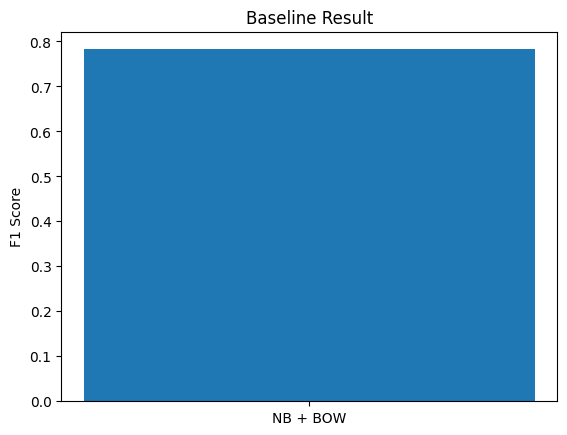

In [5]:
import re
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import os
import time
import json
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report



#CONFIGURACIÓN MLFLOW

mlflow.set_tracking_uri("http://ec2-3-87-48-179.compute-1.amazonaws.com:5000")

experiment_name = "Parcial_NLP"

try:
    exp = mlflow.get_experiment_by_name(experiment_name)
    if exp is None:
        experiment_id = mlflow.create_experiment(experiment_name)
    else:
        experiment_id = exp.experiment_id
except Exception as e:
    print(f"Error al conectar con MLflow: {e}")
    experiment_id = "0"


#CREAR CARPETAS OUTPUT

os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)
os.makedirs("data", exist_ok=True)


#CARGAR DATASET

dataset = load_dataset("adilbekovich/Sentiment140Twitter")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print(train_df.head())


#LIMPIEZA DE TEXTO

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text


train_df["text"] = train_df["text"].map(clean_text)
test_df["text"] = test_df["text"].map(clean_text)


#GUARDAR DATA LIMPIA

train_clean_path = "data/train_clean.csv"
test_clean_path = "data/test_clean.csv"

train_df.to_csv(train_clean_path, index=False)
test_df.to_csv(test_clean_path, index=False)

print("Datasets preprocesados guardados.")


#FEATURES Y LABELS

X_train_text = train_df["text"]
y_train = train_df["label"]

X_test_text = test_df["text"]
y_test = test_df["label"]


#VECTORIZACIÓN

vectorizer = CountVectorizer()

start_time = time.time()

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("BAG OF WORDS")
print("Tamaño vocabulario:", len(vectorizer.vocabulary_))
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)


#PARÁMETROS

params = {
    "model": "MultinomialNB",
    "vectorizer": "CountVectorizer",
    "alpha": 1.0,
    "dataset": "Sentiment140"
}


mlflow.sklearn.autolog()


#ENTRENAMIENTO

with mlflow.start_run(experiment_id=experiment_id, run_name="Baseline_BOW_MultinomialNB"):

    model = MultinomialNB(alpha=params["alpha"])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred, average='weighted')

    end_time = time.time()
    execution_time = end_time - start_time


    #LOG PARAMS

    mlflow.log_params(params)


    #LOG METRICS

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("runtime_seconds", execution_time)


    #TAGS

    mlflow.set_tag("dataset", "Sentiment140")
    mlflow.set_tag("feature_type", "BagOfWords")
    mlflow.set_tag("model_type", "NaiveBayes")
    mlflow.set_tag("evaluation_metric", "f1_score")
    mlflow.set_tag("experiment_stage", "baseline")
    mlflow.set_tag("author", "Nicolas")
    mlflow.set_tag("sagemaker_ready", "true")
    mlflow.set_tag("execution_time_seconds", round(execution_time, 2))
    mlflow.set_tag("f1_score_result", round(f1, 4))


    #MODEL CARD

    model_card = {
        "model_name": "Baseline Sentiment140",
        "vectorizer": "CountVectorizer",
        "classifier": "MultinomialNB",
        "dataset": "Sentiment140",
        "f1_score": float(f1),
        "author": "Nicolas"
    }

    with open("outputs/model/model_card.json", "w") as f:
        json.dump(model_card, f, indent=4)


    #BASELINE TABLE

    baseline_df = pd.DataFrame([{
        "vectorizer": "CountVectorizer",
        "model": "MultinomialNB",
        "f1_score": f1,
        "author": "Nicolas"
    }])

    baseline_df.to_csv("outputs/reports/baseline_results.csv", index=False)


    #BASELINE PLOT

    plt.figure()
    plt.bar(["NB + BOW"], [f1])
    plt.ylabel("F1 Score")
    plt.title("Baseline Result")
    plt.savefig("outputs/reports/baseline_plot.png")


    #BASELINE SUMMARY

    summary = f"""
Baseline experiment using Bag of Words and Multinomial Naive Bayes.

The model achieved an F1-score of {f1:.4f} on the Sentiment140 dataset.

This experiment serves as the reference baseline for the ablation study.
"""

    with open("outputs/reports/baseline_summary.txt", "w") as f:
        f.write(summary)


    #COMPARISON

    comparison = {
        "our_model": {
            "model": "MultinomialNB",
            "f1_score": float(f1),
            "runtime_seconds": execution_time
        },
        "hf_model": {
            "model": "distilbert-base-uncased",
            "f1_score": None,
            "runtime_seconds": None
        }
    }

    with open("outputs/reports/comparison.json", "w") as f:
        json.dump(comparison, f, indent=4)


    #WORK DISTRIBUTION

    work_df = pd.DataFrame([{
        "member": "Nicolas",
        "experiment": "Baseline NB + BOW"
    }])

    work_df.to_csv("outputs/reports/work_distribution.csv", index=False)


    #LOG ARTIFACTS

    mlflow.log_artifact("outputs/model/model_card.json")

    mlflow.log_artifact("outputs/reports/baseline_results.csv")
    mlflow.log_artifact("outputs/reports/baseline_plot.png")
    mlflow.log_artifact("outputs/reports/baseline_summary.txt")
    mlflow.log_artifact("outputs/reports/comparison.json")
    mlflow.log_artifact("outputs/reports/work_distribution.csv")


    #RESULTADOS

    print("\nEjecución Exitosa")
    print(f"Experimento: {experiment_name} (ID: {experiment_id})")
    print(f"F1 Score final: {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


#COMPARATIVA

print("\nComparativa de resultados:")

comparison_df = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred
})

print(comparison_df.head())


#VOCABULARIO

feature_names = np.array(vectorizer.get_feature_names_out())